Carregando dados...

Shape dos dados: (105612, 409)

Primeiras linhas:
   PROFICIENCIA_LP_SAEB  PROFICIENCIA_MT_SAEB  ID_AREA_Interior  \
0            180.067546            281.892650                 1   
1            291.618108            344.644699                 1   
2            274.153291            328.590243                 1   
3            280.046628            260.857237                 1   
4            330.728225            307.301805                 1   

   IN_PUBLICA_Pública  ID_LOCALIZACAO_Urbana  TX_RESP_Q01_Masculino  \
0                   1                      1                      1   
1                   1                      1                      0   
2                   1                      1                      1   
3                   1                      1                      0   
4                   1                      1                      1   

   TX_RESP_Q02_17 anos  TX_RESP_Q02_18 anos  TX_RESP_Q02_19 anos  \
0                    1         

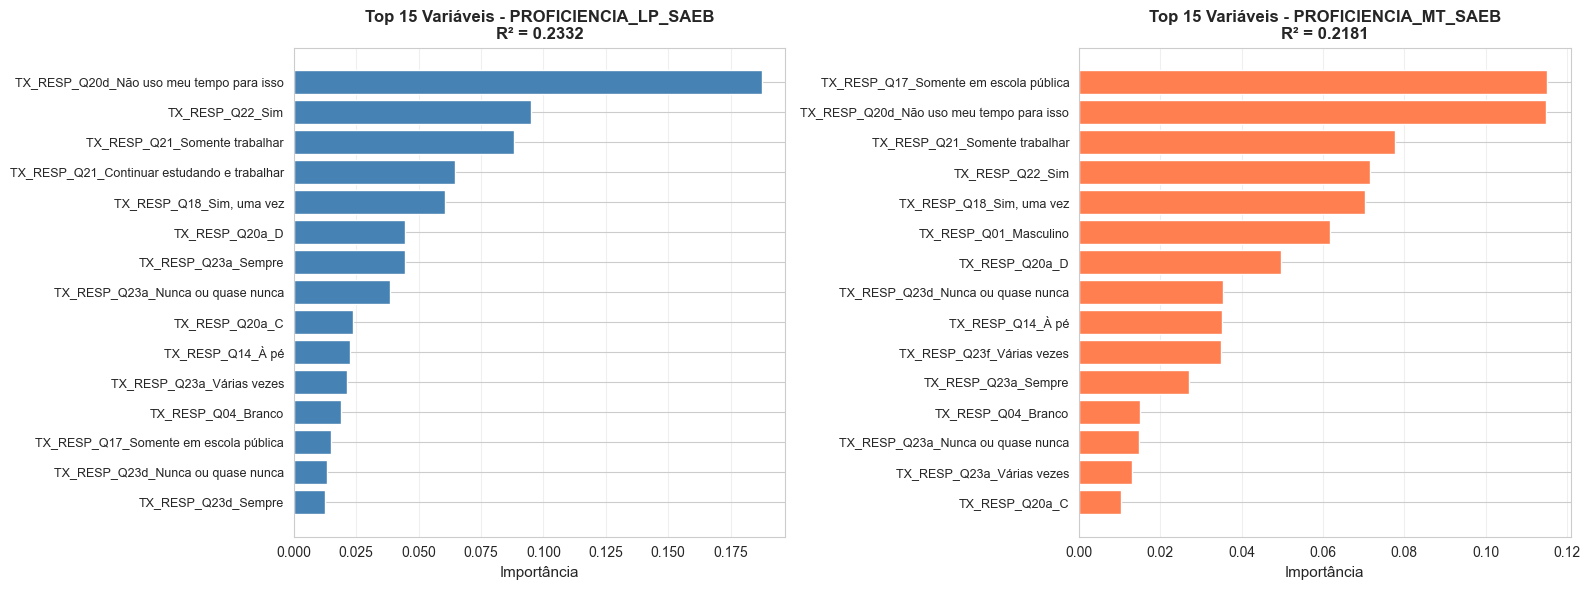


Arquivos salvos:
  - importancia_LP_SAEB.csv
  - importancia_MT_SAEB.csv

COMPARAÇÃO DAS TOP 10 VARIÁVEIS

Variáveis importantes em ambas as proficiências:
                                   Variavel  Import_LP  Import_MT
                      TX_RESP_Q01_Masculino   0.000000   0.061816
                           TX_RESP_Q14_À pé   0.022656   0.035104
      TX_RESP_Q17_Somente em escola pública   0.000000   0.115121
                   TX_RESP_Q18_Sim, uma vez   0.060694   0.070427
                             TX_RESP_Q20a_C   0.023787   0.000000
                             TX_RESP_Q20a_D   0.044739   0.049725
   TX_RESP_Q20d_Não uso meu tempo para isso   0.187590   0.114847
TX_RESP_Q21_Continuar estudando e trabalhar   0.064382   0.000000
              TX_RESP_Q21_Somente trabalhar   0.088392   0.077702
                            TX_RESP_Q22_Sim   0.094966   0.071643
          TX_RESP_Q23a_Nunca ou quase nunca   0.038417   0.000000
                        TX_RESP_Q23a_Sempre   0.044

In [12]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 1. Carregar os dados
print("Carregando dados...")
df = pd.read_csv('../Dados_Saeb_2021/DADOS/dados_final_binario.csv')

# Exibir informações básicas
print(f"\nShape dos dados: {df.shape}")
print(f"\nPrimeiras linhas:\n{df.head()}")
print(f"\nInformações das variáveis:\n{df.info()}")

# 2. Separar variáveis dependentes e independentes
variaveis_dependentes = ['PROFICIENCIA_LP_SAEB', 'PROFICIENCIA_MT_SAEB']
variaveis_independentes = [col for col in df.columns if col not in variaveis_dependentes]

print(f"\nNúmero de variáveis independentes: {len(variaveis_independentes)}")
print(f"Variáveis independentes: {variaveis_independentes}")

# Remover linhas com valores faltantes nas variáveis de interesse
df_clean = df.dropna(subset=variaveis_dependentes)
print(f"\nDados após remover NAs: {df_clean.shape}")

# 3. Preparar features (X) - apenas variáveis independentes
X = df_clean[variaveis_independentes]

# Verificar e tratar valores faltantes nas variáveis independentes
# if X.isnull().sum().sum() > 0:
#     print("\nPreenchendo valores faltantes nas variáveis independentes com 0...")
#     X = X.fillna(0)

# 4. Função para análise de importância
def analisar_importancia(X, y, nome_variavel, n_estimators=100, random_state=42):
    """
    Treina Random Forest e retorna importância das variáveis
    """
    print(f"\n{'='*60}")
    print(f"ANÁLISE PARA: {nome_variavel}")
    print(f"{'='*60}")

    # Dividir dados em treino e teste
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    # Treinar Random Forest
    print(f"\nTreinando Random Forest com {n_estimators} árvores...")
    rf_model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=random_state,
        n_jobs=-1
    )

    rf_model.fit(X_train, y_train)

    # Fazer previsões
    y_pred = rf_model.predict(X_test)

    # Métricas de performance
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\nMétricas do modelo:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MSE: {mse:.4f}")

    # Obter importâncias
    importancias = pd.DataFrame({
        'Variavel': X.columns,
        'Importancia': rf_model.feature_importances_
    }).sort_values('Importancia', ascending=False)

    return rf_model, importancias, r2, rmse

# 5. Análise para PROFICIENCIA_LP_SAEB
y_lp = df_clean['PROFICIENCIA_LP_SAEB']
modelo_lp, importancias_lp, r2_lp, rmse_lp = analisar_importancia(
    X, y_lp, 'PROFICIENCIA_LP_SAEB', n_estimators=500
)

print(f"\nTop 20 variáveis mais importantes para PROFICIENCIA_LP_SAEB:")
print(importancias_lp.head(20).to_string(index=False))

# 6. Análise para PROFICIENCIA_MT_SAEB
y_mt = df_clean['PROFICIENCIA_MT_SAEB']
modelo_mt, importancias_mt, r2_mt, rmse_mt = analisar_importancia(
    X, y_mt, 'PROFICIENCIA_MT_SAEB', n_estimators=500
)

print(f"\nTop 20 variáveis mais importantes para PROFICIENCIA_MT_SAEB:")
print(importancias_mt.head(20).to_string(index=False))

# 7. Visualizações
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico para LP
top_n = 15
importancias_lp_top = importancias_lp.head(top_n)
axes[0].barh(range(top_n), importancias_lp_top['Importancia'], color='steelblue')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(importancias_lp_top['Variavel'], fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Importância', fontsize=11)
axes[0].set_title(f'Top {top_n} Variáveis - PROFICIENCIA_LP_SAEB\nR² = {r2_lp:.4f}',
                  fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Gráfico para MT
importancias_mt_top = importancias_mt.head(top_n)
axes[1].barh(range(top_n), importancias_mt_top['Importancia'], color='coral')
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(importancias_mt_top['Variavel'], fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Importância', fontsize=11)
axes[1].set_title(f'Top {top_n} Variáveis - PROFICIENCIA_MT_SAEB\nR² = {r2_mt:.4f}',
                  fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('importancia_variaveis_saeb.png', dpi=300, bbox_inches='tight')
print("\nGráfico salvo como 'importancia_variaveis_saeb.png'")
plt.show()

# 8. Salvar resultados em CSV
importancias_lp.to_csv('importancia_LP_SAEB.csv', index=False)
importancias_mt.to_csv('importancia_MT_SAEB.csv', index=False)
print("\nArquivos salvos:")
print("  - importancia_LP_SAEB.csv")
print("  - importancia_MT_SAEB.csv")

# 9. Comparação das variáveis mais importantes
print(f"\n{'='*60}")
print("COMPARAÇÃO DAS TOP 10 VARIÁVEIS")
print(f"{'='*60}")

comparacao = pd.merge(
    importancias_lp.head(10)[['Variavel', 'Importancia']].rename(columns={'Importancia': 'Import_LP'}),
    importancias_mt.head(10)[['Variavel', 'Importancia']].rename(columns={'Importancia': 'Import_MT'}),
    on='Variavel',
    how='outer'
).fillna(0)

print("\nVariáveis importantes em ambas as proficiências:")
print(comparacao.to_string(index=False))

Carregando dados...
Dados carregados com sucesso. Shape: (105612, 409)

INICIANDO TREINAMENTO PARA: PROFICIENCIA_LP_SAEB
Dados de treino: (84489, 407), Dados de teste: (21123, 407)

Instanciando modelo com parâmetros otimizados...
Treinando o modelo...
Realizando previsões no conjunto de teste...

>> Métricas de Desempenho para 'PROFICIENCIA_LP_SAEB':
   R² Score: 0.3006
   RMSE (Root Mean Squared Error): 38.1884

Top 20 variáveis mais importantes (LP):
                                                                      Variavel  Importancia
0                                     TX_RESP_Q20d_Não uso meu tempo para isso     0.061453
1                                                              TX_RESP_Q22_Sim     0.039468
2                                                TX_RESP_Q21_Somente trabalhar     0.036325
3                                                     TX_RESP_Q18_Sim, uma vez     0.027639
4                                                          TX_RESP_Q23a_Sempre    

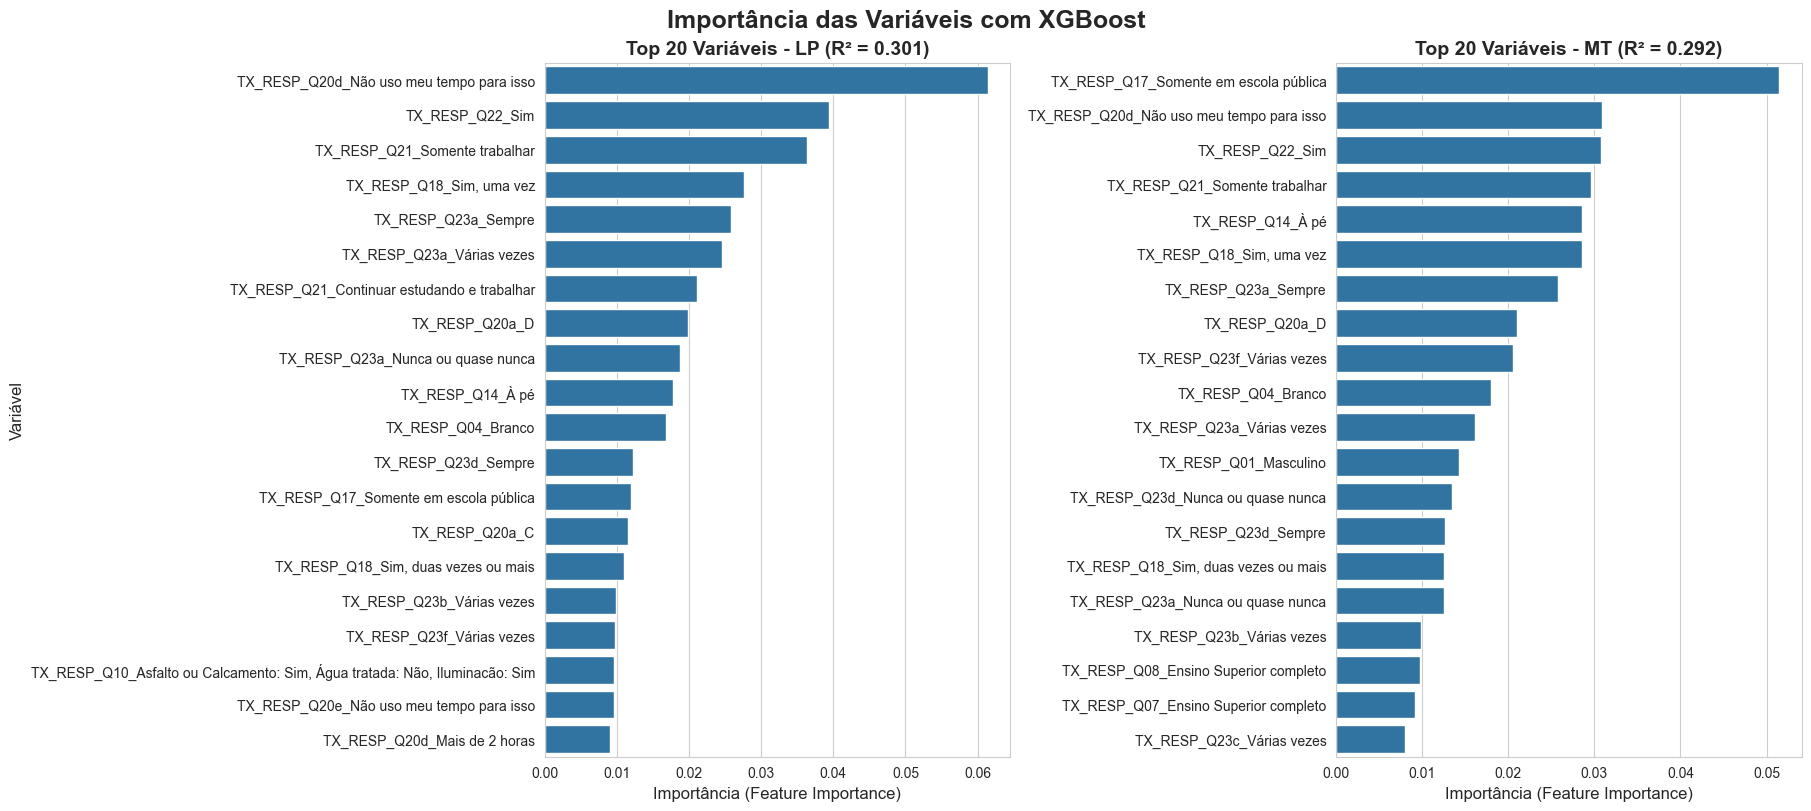


--- Aplicação concluída ---


In [15]:
# =================================================================
# Aplicação de XGBoost com Parâmetros Otimizados (GPU)
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# Configurações de visualização
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (18, 8)


# 1. PARÂMETROS OTIMIZADOS (fornecidos por você)
# Estes são os melhores parâmetros encontrados na etapa de RandomizedSearchCV
# e serão usados diretamente para construir nosso modelo final.
MELHORES_PARAMETROS = {
    'subsample': 0.6,
    'n_estimators': 1000,
    'min_child_weight': 3,
    'max_depth': 4,
    'learning_rate': 0.04,
    'colsample_bytree': 0.6
}


def treinar_e_avaliar_modelo(X, y, nome_variavel, parametros_modelo):
    """
    Executa o pipeline completo de treino e avaliação para uma variável alvo.
    """
    print(f"\n{'='*60}")
    print(f"INICIANDO TREINAMENTO PARA: {nome_variavel}")
    print(f"{'='*60}")

    # a. Dividir dados em treino e teste
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    print(f"Dados de treino: {X_train.shape}, Dados de teste: {X_test.shape}")

    # b. Instanciar o modelo XGBoost com os MELHORES PARÂMETROS
    # Note que passamos os parâmetros diretamente usando **parametros_modelo
    print("\nInstanciando modelo com parâmetros otimizados...")
    modelo = XGBRegressor(
        objective='reg:squarederror',
        tree_method='gpu_hist',      # Use 'hist' se não tiver GPU
        predictor='gpu_predictor',   # Remova esta linha se não tiver GPU
        random_state=42,
        **parametros_modelo          # Desempacota o dicionário de parâmetros aqui
    )

    # c. Treinar o modelo
    print("Treinando o modelo...")
    modelo.fit(X_train, y_train)

    # d. Fazer previsões no conjunto de teste
    print("Realizando previsões no conjunto de teste...")
    y_pred = modelo.predict(X_test)

    # e. Avaliar o desempenho
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\n>> Métricas de Desempenho para '{nome_variavel}':")
    print(f"   R² Score: {r2:.4f}")
    print(f"   RMSE (Root Mean Squared Error): {rmse:.4f}")

    # f. Extrair importância das variáveis
    importancias = pd.DataFrame({
        'Variavel': X.columns,
        'Importancia': modelo.feature_importances_
    }).sort_values('Importancia', ascending=False).reset_index(drop=True)

    return importancias, r2


# Bloco principal de execução
if __name__ == "__main__":
    # 2. Carregar os dados
    try:
        print("Carregando dados...")
        df = pd.read_csv('../Dados_Saeb_2021/DADOS/dados_final_binario.csv')
        print(f"Dados carregados com sucesso. Shape: {df.shape}")
    except FileNotFoundError:
        print("\nERRO: O arquivo 'dados_final_binario.csv' não foi encontrado.")
        exit()

    # 3. Preparar os dados
    variaveis_dependentes = ['PROFICIENCIA_LP_SAEB', 'PROFICIENCIA_MT_SAEB']
    variaveis_independentes = [col for col in df.columns if col not in variaveis_dependentes]

    df_clean = df.dropna(subset=variaveis_dependentes).copy()
    X = df_clean[variaveis_independentes].fillna(0)
    
    # 4. Executar para PROFICIENCIA_LP_SAEB
    y_lp = df_clean['PROFICIENCIA_LP_SAEB']
    importancias_lp, r2_lp = treinar_e_avaliar_modelo(
        X, y_lp, 'PROFICIENCIA_LP_SAEB', MELHORES_PARAMETROS
    )
    print("\nTop 20 variáveis mais importantes (LP):")
    print(importancias_lp.head(20).to_string())

    # 5. Executar para PROFICIENCIA_MT_SAEB
    y_mt = df_clean['PROFICIENCIA_MT_SAEB']
    importancias_mt, r2_mt = treinar_e_avaliar_modelo(
        X, y_mt, 'PROFICIENCIA_MT_SAEB', MELHORES_PARAMETROS
    )
    print("\nTop 20 variáveis mais importantes (MT):")
    print(importancias_mt.head(20).to_string())

    # 6. Visualizar a importância das variáveis
    print("\nGerando gráficos de importância das variáveis...")
    fig, axes = plt.subplots(1, 2, constrained_layout=True)
    top_n = 20

    importancias_lp.to_csv('importancia_LP_SAEB.csv', index=False)
    importancias_mt.to_csv('importancia_MT_SAEB.csv', index=False)

    # Gráfico para LP
    sns.barplot(x='Importancia', y='Variavel', data=importancias_lp.head(top_n), ax=axes[0])
    axes[0].set_title(f'Top {top_n} Variáveis - LP (R² = {r2_lp:.3f})', fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Importância (Feature Importance)", fontsize=12)
    axes[0].set_ylabel("Variável", fontsize=12)

    # Gráfico para MT
    sns.barplot(x='Importancia', y='Variavel', data=importancias_mt.head(top_n), ax=axes[1])
    axes[1].set_title(f'Top {top_n} Variáveis - MT (R² = {r2_mt:.3f})', fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Importância (Feature Importance)", fontsize=12)
    axes[1].set_ylabel("") # Remove o label y para um visual mais limpo

    plt.suptitle("Importância das Variáveis com XGBoost", fontsize=18, fontweight='bold')
    plt.savefig('importancia_variaveis_modelo_otimizado.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n--- Aplicação concluída ---")

Testando com dados de 2023

In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 7)

# 1. Carregar os dados de treino (2021) e teste (2023)
print("Carregando dados de treino (SAEB 2021)...")
# ATENÇÃO: Confirme se o caminho para o arquivo de 2021 está correto.
df_train = pd.read_csv('../Dados_Saeb_2021/DADOS/dados_final_binario.csv')
print(f"Shape dos dados de treino (2021): {df_train.shape}")
print(f"Primeiras linhas (2021):\n{df_train.head()}")

print("\n" + "="*80 + "\n")

print("Carregando dados de teste (SAEB 2023)...")
# ATENÇÃO: Ajuste o caminho e o nome do arquivo de 2023 conforme necessário.
df_test = pd.read_csv('../Dados_Saeb_2023/DADOS/dados_final_binario.csv')
print(f"Shape dos dados de teste (2023): {df_test.shape}")
print(f"Primeiras linhas (2023):\n{df_test.head()}")


# 2. Separar variáveis dependentes e independentes (baseado nos dados de treino)
variaveis_dependentes = ['PROFICIENCIA_LP_SAEB', 'PROFICIENCIA_MT_SAEB']
variaveis_independentes = [col for col in df_train.columns if col not in variaveis_dependentes]

print(f"\nNúmero de variáveis independentes: {len(variaveis_independentes)}")

# 3. Preparar os dados de treino (2021)
df_train_clean = df_train.dropna(subset=variaveis_dependentes)
X_train = df_train_clean[variaveis_independentes]
y_train_lp = df_train_clean['PROFICIENCIA_LP_SAEB']
y_train_mt = df_train_clean['PROFICIENCIA_MT_SAEB']
print(f"\nDados de treino (2021) após remover NAs: {df_train_clean.shape}")

# 4. Preparar os dados de teste (2023)
df_test_clean = df_test.dropna(subset=variaveis_dependentes)
X_test = df_test_clean[variaveis_independentes]
y_test_lp = df_test_clean['PROFICIENCIA_LP_SAEB']
y_test_mt = df_test_clean['PROFICIENCIA_MT_SAEB']
print(f"Dados de teste (2023) após remover NAs: {df_test_clean.shape}")


# 5. ALINHAMENTO DE COLUNAS (Passo Crítico)
# Garante que X_test tenha exatamente as mesmas colunas que X_train
print("\nAlinhando colunas entre os datasets de treino e teste...")
train_cols = X_train.columns
X_test = X_test.reindex(columns=train_cols, fill_value=0)
print("Alinhamento concluído.")

# 6. Função para treinar o modelo e avaliar no novo conjunto de dados
def treinar_e_avaliar_modelo(X_train, y_train, X_test, y_test, nome_variavel, n_estimators=100, random_state=42):
    """
    Treina Random Forest com dados de 2021 e avalia com dados de 2023.
    """
    print(f"\n{'='*60}")
    print(f"ANÁLISE PARA: {nome_variavel}")
    print(f"{'='*60}")

    # Treinar Random Forest com os dados de 2021
    print(f"\nTreinando Random Forest com {n_estimators} árvores nos dados de 2021...")
    rf_model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=random_state,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    print("Treinamento concluído.")

    # Fazer previsões nos dados de 2023
    print("Avaliando o modelo nos dados de 2023...")
    y_pred = rf_model.predict(X_test)

    # Métricas de performance (Assertividade)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\nMétricas de performance do modelo (avaliado em dados de 2023):")
    print(f"  R² Score: {r2:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MSE: {mse:.4f}")

    # Obter importâncias (derivadas do modelo treinado em 2021)
    importancias = pd.DataFrame({
        'Variavel': X_train.columns,
        'Importancia': rf_model.feature_importances_
    }).sort_values('Importancia', ascending=False)

    return rf_model, importancias, r2, rmse

# 7. Análise para PROFICIENCIA_LP_SAEB
modelo_lp, importancias_lp, r2_lp, rmse_lp = treinar_e_avaliar_modelo(
    X_train, y_train_lp, X_test, y_test_lp, 'PROFICIENCIA_LP_SAEB', n_estimators=500
)

print(f"\nTop 20 variáveis mais importantes para PROFICIENCIA_LP_SAEB (baseado no treino de 2021):")
print(importancias_lp.head(20).to_string(index=False))

# 8. Análise para PROFICIENCIA_MT_SAEB
modelo_mt, importancias_mt, r2_mt, rmse_mt = treinar_e_avaliar_modelo(
    X_train, y_train_mt, X_test, y_test_mt, 'PROFICIENCIA_MT_SAEB', n_estimators=500
)

print(f"\nTop 20 variáveis mais importantes para PROFICIENCIA_MT_SAEB (baseado no treino de 2021):")
print(importancias_mt.head(20).to_string(index=False))

# 9. Visualizações
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
top_n = 15

# Gráfico para LP
importancias_lp_top = importancias_lp.head(top_n)
axes[0].barh(range(top_n), importancias_lp_top['Importancia'], color='steelblue')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(importancias_lp_top['Variavel'], fontsize=10)
axes[0].invert_yaxis()
axes[0].set_xlabel('Importância', fontsize=12)
axes[0].set_title(f'Top {top_n} Variáveis - PROFICIENCIA_LP_SAEB\n(Treino 2021 | Teste 2023: R² = {r2_lp:.4f})',
                  fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Gráfico para MT
importancias_mt_top = importancias_mt.head(top_n)
axes[1].barh(range(top_n), importancias_mt_top['Importancia'], color='coral')
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(importancias_mt_top['Variavel'], fontsize=10)
axes[1].invert_yaxis()
axes[1].set_xlabel('Importância', fontsize=12)
axes[1].set_title(f'Top {top_n} Variáveis - PROFICIENCIA_MT_SAEB\n(Treino 2021 | Teste 2023: R² = {r2_mt:.4f})',
                  fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('importancia_variaveis_saeb_treino2021_teste2023.png', dpi=300, bbox_inches='tight')
print("\nGráfico salvo como 'importancia_variaveis_saeb_treino2021_teste2023.png'")
plt.show()

# 10. Salvar resultados e comparação
# (Esta parte permanece a mesma, pois a importância das variáveis é calculada a partir do modelo treinado)
importancias_lp.to_csv('importancia_LP_SAEB.csv', index=False)
importancias_mt.to_csv('importancia_MT_SAEB.csv', index=False)
print("\nArquivos de importância salvos.")

print(f"\n{'='*60}")
print("COMPARAÇÃO DAS TOP 10 VARIÁVEIS (BASEADO NO TREINO DE 2021)")
print(f"{'='*60}")
comparacao = pd.merge(
    importancias_lp.head(10)[['Variavel', 'Importancia']].rename(columns={'Importancia': 'Import_LP'}),
    importancias_mt.head(10)[['Variavel', 'Importancia']].rename(columns={'Importancia': 'Import_MT'}),
    on='Variavel',
    how='outer'
).fillna(0)
print("\nVariáveis importantes em ambas as proficiências:")
print(comparacao.to_string(index=False))

Carregando dados de treino (SAEB 2021)...
Shape dos dados de treino (2021): (146274, 146)
Primeiras linhas (2021):
   PROFICIENCIA_LP_SAEB  PROFICIENCIA_MT_SAEB  ID_AREA_2  IN_PUBLICA_1  \
0            180.067546            281.892650          1             1   
1            300.524997            334.841520          1             1   
2            291.618108            344.644699          1             1   
3            274.153291            328.590243          1             1   
4            280.046628            260.857237          1             1   

   ID_LOCALIZACAO_2  TX_RESP_Q01_B  TX_RESP_Q02_B  TX_RESP_Q02_C  \
0                 0              0              1              0   
1                 0              1              1              0   
2                 0              1              1              0   
3                 0              0              1              0   
4                 0              1              0              1   

   TX_RESP_Q02_D  TX_RESP_Q02_E

KeyError: "['TX_RESP_Q05_B', 'TX_RESP_Q06a_B', 'TX_RESP_Q06b_B', 'TX_RESP_Q06c_B', 'TX_RESP_Q06d_B', 'TX_RESP_Q06e_B', 'TX_RESP_Q07_B', 'TX_RESP_Q07_C', 'TX_RESP_Q07_D', 'TX_RESP_Q07_E', 'TX_RESP_Q07_F', 'TX_RESP_Q09a_B', 'TX_RESP_Q09a_C', 'TX_RESP_Q09b_B', 'TX_RESP_Q09b_C', 'TX_RESP_Q09c_B', 'TX_RESP_Q09c_C', 'TX_RESP_Q09d_B', 'TX_RESP_Q09d_C', 'TX_RESP_Q09e_B', 'TX_RESP_Q09e_C', 'TX_RESP_Q09f_B', 'TX_RESP_Q09f_C', 'TX_RESP_Q11a_C', 'TX_RESP_Q11a_D', 'TX_RESP_Q11b_C', 'TX_RESP_Q11b_D', 'TX_RESP_Q11c_C', 'TX_RESP_Q11c_D', 'TX_RESP_Q11d_B', 'TX_RESP_Q11d_C', 'TX_RESP_Q11d_D', 'TX_RESP_Q11e_B', 'TX_RESP_Q11e_C', 'TX_RESP_Q11e_D', 'TX_RESP_Q11f_B', 'TX_RESP_Q11f_C', 'TX_RESP_Q11f_D', 'TX_RESP_Q11g_B', 'TX_RESP_Q11g_C', 'TX_RESP_Q11g_D', 'TX_RESP_Q11h_B', 'TX_RESP_Q11h_C', 'TX_RESP_Q11h_D', 'TX_RESP_Q12h_B', 'TX_RESP_Q12i_B', 'TX_RESP_Q13_B', 'TX_RESP_Q13_C', 'TX_RESP_Q14_D', 'TX_RESP_Q14_E', 'TX_RESP_Q14_F', 'TX_RESP_Q14_G', 'TX_RESP_Q15_B', 'TX_RESP_Q20a_B', 'TX_RESP_Q20a_C', 'TX_RESP_Q2